## 1. 데이터 확인

In [1]:
# 데이터 불러오기 및 확인
import pandas as pd
df = pd.read_csv('../raw_data/concatenated_data_2.csv')
df.head()

,Post_ID,Type,Data,Timestamp
0,1kf6ohc,0,What is the obsession with ChatGPT nowadays???,2025-05-05 17:38:45
1,1kf6ohc,1,"""Oh you want to know more about it? Just use C...",2025-05-05 17:38:45
2,1kf6ohc,2,**Reminder:** \n\nThis is a support space. **...,2025-05-05 17:38:46
3,1kf6ohc,2,"One time, a professor assigned my group with a...",2025-05-05 18:42:29
4,1kf6ohc,2,"I agree with you, what I find really surprison...",2025-05-05 17:41:19


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60359 entries, 0 to 60358
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Post_ID    60359 non-null  object
 1   Type       60359 non-null  int64 
 2   Data       60359 non-null  object
 3   Timestamp  60359 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.8+ MB


## 2. 게시글 검수

In [3]:
# 여기서 모든 계시글을 읽고 filter_junk=[,]에 index 적음
# cluade(가수,화가 등),gemini(별자리) 관련없는 계시글 다수 있음
df_post = df[df['Type'] == 0]
df_post

,Post_ID,Type,Data,Timestamp
0,1kf6ohc,0,What is the obsession with ChatGPT nowadays???,2025-05-05 17:38:45
463,1ki5akm,0,I asked ChatGPT to tell the biggest lie ever s...,2025-05-09 09:11:36
960,1kerkh1,0,Is my boss using ChatGPT to email me?,2025-05-05 04:03:47
1454,1kneerk,0,College student asks for her tuition fees back...,2025-05-16 02:42:24
1945,1kqt5kp,0,I asked ChatGPT to colorize my old yearbook ph...,2025-05-20 10:41:44
...,...,...,...,...
58327,1kypl62,0,"What's the most unexpected, actually useful th...",2025-05-30 08:34:11
58823,1ku3d9n,0,ChatGPT,2025-05-24 13:39:03
59026,1kw36jt,0,"Wait, ChatGPT has to reread the entire chat hi...",2025-05-27 04:27:45
59512,1kzy7ju,0,"Just worried, my gf keeps using ChatGPT for an...",2025-05-31 23:20:07


In [4]:
# 계시글 일일이 확인 
filter_junk=[10149,12341,12813,22647,24579,24742,26943,27314,28328,44304,46615,46823,47033,48106,48420,48964,51659]

In [5]:
# 계시글 수
len(filter_junk)

17

In [6]:
filter_post_ids = df.loc[filter_junk, 'Post_ID'].tolist()
print(filter_post_ids)

['1ku7qkf', '1kvcex7', '1ktyp6t', '1l49apf', '1l6phpy', '1lahsfi', '1lcymkn', '1l9bbj3', '1l0bfaq', '1l1dod9', '1kqtqn7', '1klya4h', '1ker6ht', '1knvn9o', '1kfsnfd', '1kjjlpt', '1kwj8q9']


In [7]:
# Post_ID가 filter_post_ids에 포함된 행 삭제
df_filtered = df[~df['Post_ID'].isin(filter_post_ids)]
# 결과 출력
df_filtered

,Post_ID,Type,Data,Timestamp
0,1kf6ohc,0,What is the obsession with ChatGPT nowadays???,2025-05-05 17:38:45
1,1kf6ohc,1,"""Oh you want to know more about it? Just use C...",2025-05-05 17:38:45
2,1kf6ohc,2,**Reminder:** \n\nThis is a support space. **...,2025-05-05 17:38:46
3,1kf6ohc,2,"One time, a professor assigned my group with a...",2025-05-05 18:42:29
4,1kf6ohc,2,"I agree with you, what I find really surprison...",2025-05-05 17:41:19
...,...,...,...,...
60354,1kwhefx,2,Yes it is,2025-05-28 05:40:44
60355,1kwhefx,2,Just use nuclear,2025-05-28 00:15:45
60356,1kwhefx,2,I'd personally assume that the energy cost per...,2025-05-28 15:23:43
60357,1kwhefx,2,"But what about ChatGPT, It must be feeling lik...",2025-05-28 03:03:55


In [8]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57916 entries, 0 to 60358
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Post_ID    57916 non-null  object
 1   Type       57916 non-null  int64 
 2   Data       57916 non-null  object
 3   Timestamp  57916 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.2+ MB


In [9]:
# 인덱스 초기화
df_filtered = df_filtered.reset_index(drop=True)

## 3.중복 데이터 제거

In [10]:
# 중복데이터 조회
df_filtered_0_dup = df_filtered[df_filtered['Type'] == 0].value_counts('Post_ID')
df_filtered_0_dup

Post_ID
1l8bffm    2
1l73a1x    2
1l9ing5    2
1kcd5d7    1
1kzzyb2    1
          ..
1ksi3d7    1
1ksk63l    1
1ksqog2    1
1ksv917    1
1leo6qb    1
Name: count, Length: 218, dtype: int64

In [11]:
# 중복된 데이터 확인
df_sorted=df_filtered.sort_values(['Post_ID','Type','Data'])
df_sorted[df_sorted['Post_ID']=='1l8bffm']

,Post_ID,Type,Data,Timestamp
24788,1l8bffm,0,Finally got Gemini MCP working with Claude Cod...,2025-06-11 06:47:15
27569,1l8bffm,0,Finally got Gemini MCP working with Claude Cod...,2025-06-11 06:47:15
24789,1l8bffm,1,Big update -> just created a solution for usin...,2025-06-11 06:47:15
27570,1l8bffm,1,Big update -> just created a solution for usin...,2025-06-11 06:47:15
24831,1l8bffm,2,1. Have Claude write in basic api access to Ge...,2025-06-11 15:59:09
...,...,...,...,...
27608,1l8bffm,2,thank u i tried and gave up last week. bless bro.,2025-06-12 16:03:22
24866,1l8bffm,2,"the question was not about complexity, and the...",2025-06-11 17:18:49
27647,1l8bffm,2,"the question was not about complexity, and the...",2025-06-11 17:18:49
24817,1l8bffm,2,u/raiansar this is epic! well done. Is there a...,2025-06-13 10:43:32


In [12]:
# 중복데이터 삭제후 중복데이터 있는지 확인
df_filtered.drop_duplicates(subset=['Post_ID', 'Type', 'Data'], keep='first',inplace=True)
df_filtered_0_dup = df_filtered[df_filtered['Type'] == 0].value_counts('Post_ID')
df_filtered = df_filtered.reset_index(drop=True)
df_filtered_0_dup

Post_ID
1kcd5d7    1
1l2ojdb    1
1kzy7ju    1
1kzzyb2    1
1l024pe    1
          ..
1ksi3d7    1
1ksk63l    1
1ksqog2    1
1ksv917    1
1leo6qb    1
Name: count, Length: 218, dtype: int64

## 4.데이터 정제

In [13]:
df = df_filtered

# 1.데이터의 값들을 소문자로 변환
df['Data'] = df['Data'].str.lower()

# 2.['chat-gpt', 'chat_gpt', 'chat gpt'] 를 'chatgpt'로 변환
df['Data'] = df['Data'].str.replace(r'chat-gpt|chat_gpt|chat gpt', 'chatgpt', case=False, regex=True)

## 여기서 데이터 확보를 위해 위해 sonnet --> cluade sonnet,o1 --> chatgpt o1,flash 2.0 --> gemini flash 2.0 등으로 변환 가능

## 5.데이터 필터링

In [14]:
keywords_list = ['chatgpt', 'claude', 'grok', 'gemini']
regex_pattern = r'|'.join(keywords_list)
filtered_data = df[df['Data'].str.contains(regex_pattern, case=False, na=False, regex=True)]
print(f"--- '{', '.join(keywords_list)}' 중 하나 이상 포함된 데이터 ---")
filtered_data.info()

--- 'chatgpt, claude, grok, gemini' 중 하나 이상 포함된 데이터 ---
<class 'pandas.core.frame.DataFrame'>
Index: 10220 entries, 0 to 57121
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Post_ID    10220 non-null  object
 1   Type       10220 non-null  int64 
 2   Data       10220 non-null  object
 3   Timestamp  10220 non-null  object
dtypes: int64(1), object(3)
memory usage: 399.2+ KB


## 6.카테고리 지정

In [15]:
# 카테고리 설정
ordered_criteria_groups = [
    ('chatgpt', 'claude', 'grok', 'gemini'),  # 4개 키워드 모두 포함
    # 3개 키워드 조합
    ('chatgpt', 'gemini', 'grok'),
    ('chatgpt', 'gemini', 'claude'),
    ('chatgpt', 'grok', 'claude'),
    ('gemini', 'grok', 'claude'),
    # 2개 키워드 조합
    ('chatgpt', 'gemini'),
    ('chatgpt', 'grok'),
    ('chatgpt', 'claude'),
    ('gemini', 'grok'),
    ('gemini', 'claude'),
    ('grok', 'claude'),
    # 1개 키워드
    ('chatgpt',), # 튜플로 만들기 위해 쉼표 추가
    ('gemini',),
    ('grok',),
    ('claude',)
]

# 결과를 저장할 'category' 열 초기화 (pandas의 NA 값 사용)
filtered_data['category'] = pd.NA

# 정의된 우선순위에 따라 각 키워드 조합을 확인하고 카테고리 할당
for keyword_tuple in ordered_criteria_groups:
    # 아직 카테고리가 할당되지 않은 행들을 대상으로 작업
    condition_not_yet_categorized = filtered_data['category'].isna()

    # 현재 키워드 튜플에 있는 모든 키워드를 포함하는지 확인하는 조건 생성
    # (True로 시작하여 각 키워드 포함 여부를 AND 연산으로 누적)
    current_combo_condition = pd.Series([True] * len(filtered_data), index=filtered_data.index)
    for keyword in keyword_tuple:
        current_combo_condition &= filtered_data['Data'].str.contains(keyword, case=False, na=False, regex=True)

    # 최종 조건: 아직 카테고리 할당 안됨 AND 현재 조합의 모든 키워드 포함
    final_mask_for_this_group = condition_not_yet_categorized & current_combo_condition

    # 조건을 만족하는 행에 현재 키워드 튜플을 문자열로 변환하여 카테고리 할당
    filtered_data.loc[final_mask_for_this_group, 'category'] = str(keyword_tuple)

print("--- 카테고리 할당 후 DataFrame ---")
print(filtered_data)
print("-" * 30 + "\n")

# 카테고리별 데이터 개수 확인 (예시)
print("--- 카테고리별 데이터 개수 ---")
print(filtered_data['category'].value_counts(dropna=False)) # dropna=False는 NA 값(카테고리 미분류)도 포함하여 계산

/var/folders/wt/523g88ps5cs2_z5dsn_yj80h0000gn/T/ipykernel_56233/625745357.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['category'] = pd.NA


--- 카테고리 할당 후 DataFrame ---
       Post_ID  Type                                               Data  \
0      1kf6ohc     0     what is the obsession with chatgpt nowadays???   
1      1kf6ohc     1  "oh you want to know more about it? just use c...   
3      1kf6ohc     2  one time, a professor assigned my group with a...   
4      1kf6ohc     2  i agree with you, what i find really surprison...   
6      1kf6ohc     2  most baffling is, when people use it to fact c...   
...        ...   ...                                                ...   
57107  1kwhefx     2  have you thought about hiring a hooker and do ...   
57113  1kwhefx     2  he doesn't have critical thinking skills. he s...   
57114  1kwhefx     2  yup - as i understand it, co2 emissions are a ...   
57120  1kwhefx     2  i'd personally assume that the energy cost per...   
57121  1kwhefx     2  but what about chatgpt, it must be feeling lik...   

                 Timestamp      category  
0      2025-05-05 17:38:45  

In [19]:
filtered_data.head(10)

,Post_ID,Type,Data,Timestamp,category
0,1kf6ohc,0,what is the obsession with chatgpt nowadays???,2025-05-05 17:38:45,"('chatgpt',)"
1,1kf6ohc,1,"""oh you want to know more about it? just use c...",2025-05-05 17:38:45,"('chatgpt',)"
3,1kf6ohc,2,"one time, a professor assigned my group with a...",2025-05-05 18:42:29,"('chatgpt',)"
4,1kf6ohc,2,"i agree with you, what i find really surprison...",2025-05-05 17:41:19,"('chatgpt',)"
6,1kf6ohc,2,"most baffling is, when people use it to fact c...",2025-05-05 18:52:42,"('chatgpt',)"
7,1kf6ohc,2,every time i see somebody ask a specific sub a...,2025-05-05 20:44:55,"('chatgpt',)"
8,1kf6ohc,2,"i have never trusted ai, because it doesn't kn...",2025-05-05 18:52:49,"('chatgpt',)"
11,1kf6ohc,2,"i honestly think most of the people saying ""ju...",2025-05-05 19:30:50,"('chatgpt',)"
12,1kf6ohc,2,when they use chatgpt to write an email and it...,2025-05-05 18:34:00,"('chatgpt',)"
15,1kf6ohc,2,there is so much misinformation in this commen...,2025-05-05 19:46:45,"('chatgpt',)"


## 7.데이터 시각화

/var/folders/wt/523g88ps5cs2_z5dsn_yj80h0000gn/T/ipykernel_56233/4218285964.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', len(sorted_counts))


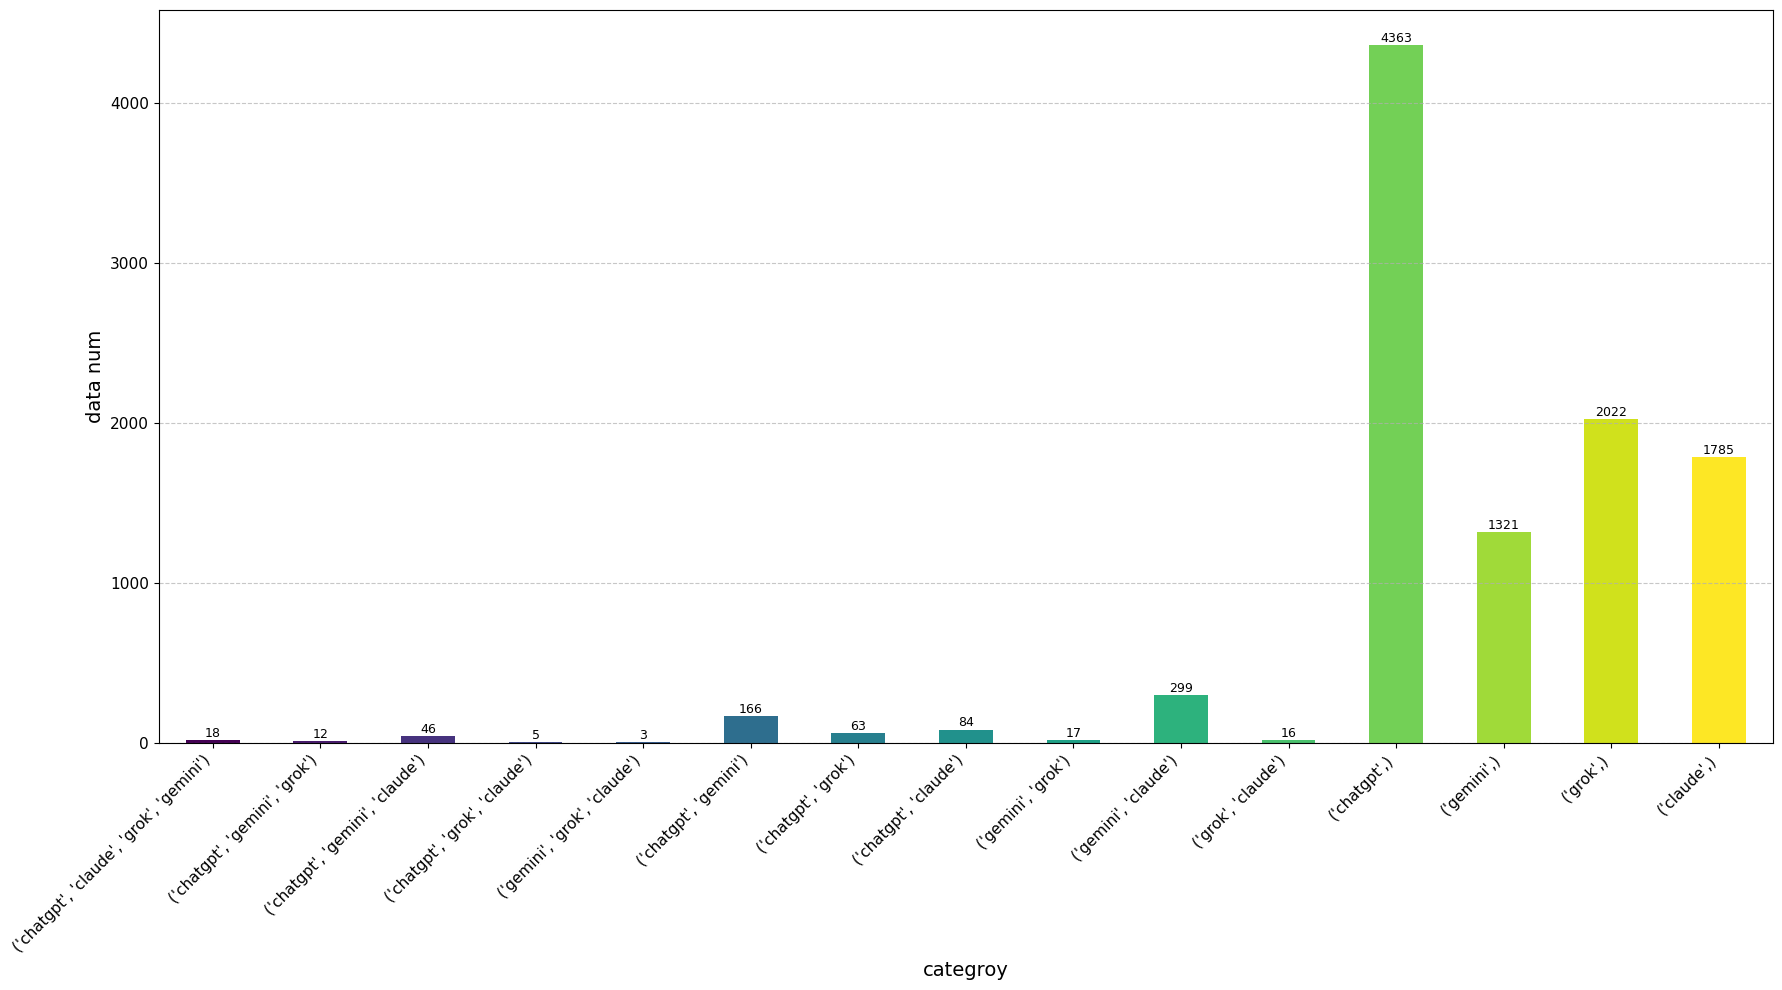

In [16]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
ordered_criteria_groups = [
    ('chatgpt', 'claude', 'grok', 'gemini'),  # 4개 키워드 모두 포함
    # 3개 키워드 조합
    ('chatgpt', 'gemini', 'grok'),
    ('chatgpt', 'gemini', 'claude'),
    ('chatgpt', 'grok', 'claude'),
    ('gemini', 'grok', 'claude'),
    # 2개 키워드 조합
    ('chatgpt', 'gemini'),
    ('chatgpt', 'grok'),
    ('chatgpt', 'claude'),
    ('gemini', 'grok'),
    ('gemini', 'claude'),
    ('grok', 'claude'),
    # 1개 키워드
    ('chatgpt',),
    ('gemini',),
    ('grok',),
    ('claude',)
]
plot_categories_filled = filtered_data['category']
category_counts = plot_categories_filled.value_counts()
plot_order_labels = [str(t) for t in ordered_criteria_groups]
sorted_counts = category_counts.reindex(plot_order_labels).fillna(0)
plt.figure(figsize=(18, 10))
colors = plt.cm.get_cmap('viridis', len(sorted_counts))
sorted_counts.plot(kind='bar', color=[colors(i) for i in range(len(sorted_counts))])
plt.ylabel('data num', fontsize=14)
plt.xlabel('categroy', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
for i, v in enumerate(sorted_counts):
    if v > 0: # 값이 0보다 클 때만 표시
        plt.text(i, v + 0.5, str(int(v)), color='black', ha='center', va='bottom', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7) # y축에 그리드 추가
plt.tight_layout() # 그래프 요소들이 겹치지 않도록 레이아웃 자동 조정
plt.show()

# 8.균일한 라벨링 위한 데이터 샘플 순서 무작위화,카테고리별 정렬,저장

In [18]:
#데이터 순서 섞기
shuffled_df = filtered_data.sample(frac=1, random_state=42).reset_index(drop=True)
shuffled_df.head(6)

,Post_ID,Type,Data,Timestamp,category
0,1ktgd82,2,"grok, why won't you support my foregone conclu...",2025-05-24 09:11:20,"('grok',)"
1,1l5h2ds,2,but if you just use it for one shots cursor wi...,2025-06-07 23:29:57,"('gemini', 'claude')"
2,1kmrxqw,2,is this the regular chatgpt or one that was tr...,2025-05-15 18:20:47,"('chatgpt',)"
3,1kf6ohc,2,"you shouldnt use chatgpt as a primary source, ...",2025-05-05 19:41:43,"('chatgpt',)"
4,1kvd8fn,2,i told claude it was useless and it agreed wit...,2025-05-26 07:34:10,"('claude',)"
5,1ktfuyv,2,i don’t understand why people aren’t using cla...,2025-05-24 00:02:31,"('claude',)"


In [24]:
#데이터 카테고리화
import numpy as np
ordered_criteria_groups = [
    ('chatgpt', 'claude', 'grok', 'gemini'),
    ('chatgpt', 'gemini', 'grok'),
    ('chatgpt', 'gemini', 'claude'),
    ('chatgpt', 'grok', 'claude'),
    ('gemini', 'grok', 'claude'),
    ('chatgpt', 'gemini'),
    ('chatgpt', 'grok'),
    ('chatgpt', 'claude'),
    ('gemini', 'grok'),
    ('gemini', 'claude'),
    ('grok', 'claude'),
    ('chatgpt',),
    ('gemini',),
    ('grok',),
    ('claude',)
]

df = shuffled_df

# 1. 라벨링을 위한 'category' 열 초기화
# 튜플(tuple)과 같은 객체를 담기 위해 데이터 타입을 'object'로 설정합니다.
df['category'] = pd.Series(dtype='object')

# 2. 우선순위에 따라 순차적으로 라벨링
unlabeled_mask = df['category'].isnull()
for group in ordered_criteria_groups:
    # 조건을 만족하고 아직 라벨이 없는 행의 인덱스를 찾습니다.
    condition = np.logical_and.reduce([df['Data'].str.contains(keyword, case=False, na=False) for keyword in group])
    target_indices = df.index[unlabeled_mask & condition]

    # 해당 행들에 튜플(group) 자체를 라벨로 직접 할당
    # .loc을 사용하여 정확한 위치에 값을 설정합니다.
    if not target_indices.empty:
        values_to_set = pd.Series([group] * len(target_indices), index=target_indices)
        df.loc[target_indices, 'category'] = values_to_set

    unlabeled_mask = df['category'].isnull()

# 3. 'category' 열을 순서가 있는 Categorical 타입으로 변환
# 카테고리의 순서는 `ordered_criteria_groups` 리스트 자체를 사용합니다.
df['category'] = pd.Categorical(df['category'], categories=ordered_criteria_groups, ordered=True)

# 4. 정의된 카테고리 순서에 따라 데이터프레임 정렬
df_sorted = df.sort_values('category')

print("\n--- 카테고리별 개수 확인 ---")
print(df_sorted['category'].value_counts())


--- 카테고리별 개수 확인 ---
category
(chatgpt,)                         4363
(grok,)                            2022
(claude,)                          1785
(gemini,)                          1321
(gemini, claude)                    299
(chatgpt, gemini)                   166
(chatgpt, claude)                    84
(chatgpt, grok)                      63
(chatgpt, gemini, claude)            46
(chatgpt, claude, grok, gemini)      18
(gemini, grok)                       17
(grok, claude)                       16
(chatgpt, gemini, grok)              12
(chatgpt, grok, claude)               5
(gemini, grok, claude)                3
Name: count, dtype: int64


In [28]:
# 새로운 열 추가
df_sorted['label(chatgpt,claude,grok,gemini)'] = np.nan
df_sorted['comment'] = np.nan
print(df_sorted)
df_sorted.info()

       Post_ID  Type                                               Data  \
7044   1kn879w     2  you're not wrong, but you are using the wrong ...   
10016  1ki5akm     2  i actually did a whole big test with a very si...   
8336   1l8bffm     2  hey i have created another post and a repo abo...   
3996   1l8bffm     2  it's written by claude so ignore the gist. i'v...   
2305   1ke770k     2  maybe it's not chatgpt, it might be claude, ge...   
...        ...   ...                                                ...   
4104   1ktwb56     2  makes sense.  i’m probably way too claude cent...   
4099   1kwucpn     2                the real alpha is claude 3.5 sonnet   
4094   1ksvb5q     2  i'm glad to see claude caught up to openai and...   
4130   1keal2w     2  yes they don't. but maybe they used to? you we...   
5109   1kdbue2     2  >also doctors are human they mess up more than...   

                 Timestamp                         category  \
7044   2025-05-16 01:33:24  (chatgpt

In [29]:
df_sorted.to_csv('processed_data_2.csv', index=False)